
**Lab 5 Mega Test**

Topics from Lab 1, 2, 3, 4: preprocessing → visualization → linear regression

**Time: 60 | Total: 100 marks**


Allowed: pandas, numpy, matplotlib/seaborn, sklearn


Rule: Write clear code with short comments. Show outputs (tables/plots).

# Dataset(Provided)
File: employee_salary.csv

Goal: Predict Salary from features (includes at least one categorical column and missing/sentinel values).

## Part A — Data Understanding + Preprocessing (Lab 1, 2) [40 marks]

### Q1. Load and understand the dataset [10]

Do the following and show the output:

1) Show the **first 5 rows** of the dataset.  
2) Show the **shape** of the dataset (rows, columns).  
3) Show the **data types** of each column.  
4) Show **how many missing values** exist per column.

### Q2. Clean missing and bad values [15]
The dataset contains missing values and may contain “sentinel” values (e.g. `"NA"`, `"?"`).

1) Detect and convert any sentinel/bad values to real missing values.  
2) Fill missing values using this rule:
- Numeric columns → fill using **mean**
- Categorical columns → fill using `"Not Available"`
3) After cleaning, show missing values per column again to prove it worked.

### Q3. Convert categorical to numeric (One-hot encoding) [15]
1) One-hot encode the categorical column(s) (e.g., `Education_Level`).  
2) Ensure the encoded columns are **0/1 numeric** (not True/False).  
3) Create:
- **X** = all input features
- **y** = target column

4) Show:
- shape of `X` and `y`
- data types of `X`

5) Explain: If you think any feature is not related to the Salary

In [ ]:
# Do Code Here

In [9]:
#Q1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('employee_salary.csv')
df.head()

,Employee_ID,Age,Education_Level,Years_Experience,Department,Performance_Score,Training_Hours,Salary
0,1,25,Bachelor,2,IT,78,20,45000
1,2,30,Master,5,Finance,85,35,62000
2,3,28,Bachelor,3,HR,80,NaN,52000
3,4,35,PhD,10,IT,92,40,90000
4,5,40,Master,12,Finance,88,38,95000


In [5]:
df.shape

(20, 8)

In [6]:
df.dtypes

,0
Employee_ID,int64
Age,int64
Education_Level,object
Years_Experience,int64
Department,object
Performance_Score,int64
Training_Hours,object
Salary,int64


In [7]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Education_Level,1
Years_Experience,0
Department,0
Performance_Score,0
Training_Hours,3
Salary,0


In [10]:
#Q2

In [8]:
df = df.replace(to_replace=[-99999,-88888,'NA','?'], value=np.nan)

In [30]:
df['Training_Hours']=df['Training_Hours'].replace(np.nan,'0')

In [31]:
df.head()

,Employee_ID,Age,Education_Level,Years_Experience,Department,Performance_Score,Training_Hours,Salary
0,1,25,Bachelor,2,IT,78,20,45000
1,2,30,Master,5,Finance,85,35,62000
2,3,28,Bachelor,3,HR,80,0,52000
3,4,35,PhD,10,IT,92,40,90000
4,5,40,Master,12,Finance,88,38,95000


In [32]:
df['Training_Hours'] = df['Training_Hours'].astype(int)

In [33]:
df['Training_Hours'].fillna(df['Training_Hours'].mean(),inplace=True)

/tmp/ipykernel_276/2527920218.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Training_Hours'].fillna(df['Training_Hours'].mean(),inplace=True)


In [35]:
df['Education_Level'].fillna('Not Available',inplace=True)

In [36]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Education_Level,0
Years_Experience,0
Department,0
Performance_Score,0
Training_Hours,0
Salary,0


In [37]:
#Q3

In [41]:
df_encoded = pd.get_dummies(df, columns=['Education_Level'],dtype=int)

In [43]:
df_encoded= pd.get_dummies(df_encoded, columns=['Department'],dtype=int)

In [44]:
df_encoded.head()

,Employee_ID,Age,Years_Experience,Performance_Score,Training_Hours,Salary,Education_Level_Bachelor,Education_Level_Master,Education_Level_Not Available,Education_Level_PhD,Department_Finance,Department_HR,Department_IT,Department_Marketing
0,1,25,2,78,20,45000,1,0,0,0,0,0,1,0
1,2,30,5,85,35,62000,0,1,0,0,1,0,0,0
2,3,28,3,80,0,52000,1,0,0,0,0,1,0,0
3,4,35,10,92,40,90000,0,0,0,1,0,0,1,0
4,5,40,12,88,38,95000,0,1,0,0,1,0,0,0


In [48]:
df_encoded.shape

(20, 14)

In [45]:
x=df_encoded.drop('Salary',axis=1)
y=df_encoded['Salary']

In [46]:
x.shape

(20, 13)

In [47]:
y.shape

(20,)

In [49]:
x.dtypes

,0
Employee_ID,int64
Age,int64
Years_Experience,int64
Performance_Score,int64
Training_Hours,int64
Education_Level_Bachelor,int64
Education_Level_Master,int64
Education_Level_Not Available,int64
Education_Level_PhD,int64
Department_Finance,int64


In [ ]:
#age and employee_id is not related to the Salary.

## Part B — Statistics + Visualization (Lab 3) [25 marks]

### Q4. Summary statistics [10]
For **`Years_Experience`**, **`Performance_Score`** and **`Salary`**, compute and show:
- mean, median, standard deviation  


### Q5. Visualization  [15]
Create plots (must include title + labeled axes):
- Histogram or KDE plot of `Salary`
- Scatter plot of `Years_Experience` vs `Salary`
- Pie plot of Education_Level

In [ ]:
# Do Code Here

In [51]:
#Q4

In [50]:
# Mean
mean_Years_Experience = df['Years_Experience'].mean()
mean_Performance_Score = df['Performance_Score'].mean()
mean_Salary=df['Salary'].mean()

# Median
median_Years_Experience = df['Years_Experience'].median()
median_price = df['Performance_Score'].median()
median_Salary=df['Salary'].median()

# Standard Deviation
std_Years_Experience = df['Years_Experience'].std()
std_Performance_Score = df['Performance_Score'].std()
std_Salary= df['Salary'].std()

In [53]:
print(mean_Years_Experience)
print(mean_Performance_Score )
print(mean_Salary)

print(median_Years_Experience )
print(median_price)
print(median_Salary)

print(std_Years_Experience)
print(std_Performance_Score)
print(std_Salary)

7.25
83.5
70400.0
6.5
83.5
66000.0
4.314906841709515
6.6213371204884215
21206.751655769294


In [54]:
#Q5

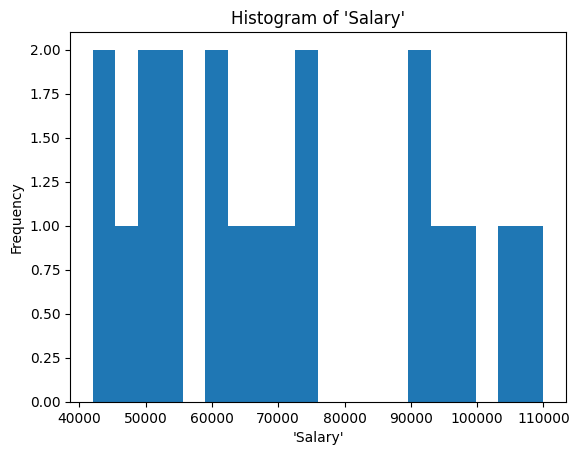

In [55]:
plt.figure()
plt.hist(df['Salary'], bins=20)
plt.title("Histogram of 'Salary'")
plt.xlabel("'Salary'")
plt.ylabel("Frequency")
plt.show()

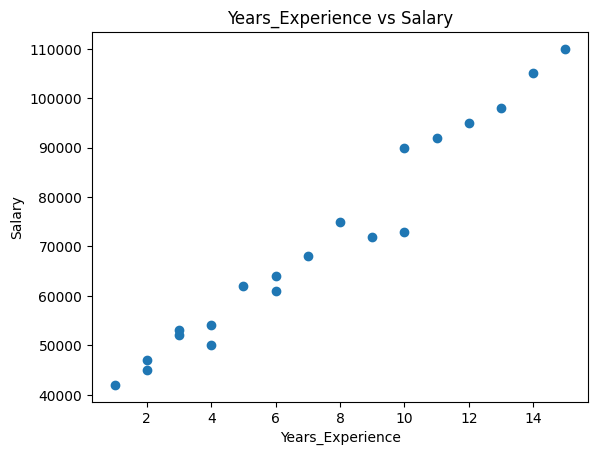

In [56]:
plt.figure()
plt.scatter(df['Years_Experience'], df['Salary'])
plt.title("Years_Experience vs Salary")
plt.xlabel("Years_Experience")
plt.ylabel("Salary")
plt.show()

In [90]:
val=df['Education_Level'].value_counts()

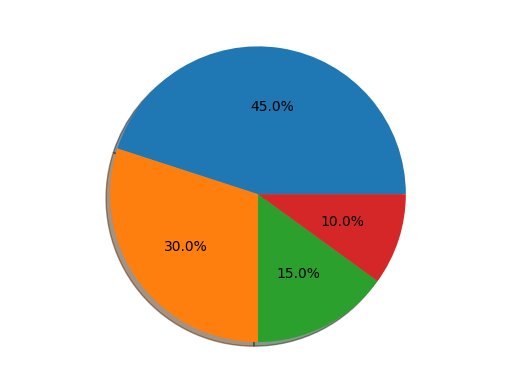

In [92]:
plt.axis('equal')
plt.pie(val, shadow=True, autopct='%1.1f%%', radius=1)
plt.show()

## Part C — Machine Learning Model (Lab 4: Linear Regression) [25 marks]

### Q7. Feature Scaling [10]

Before training the model, scale the **numeric features in X** using **two different scaling techniques separately**:

1. **Min–Max Normalization**
2. **Standardization (Z-score)**

For **each scaling method**, perform the following:

- Apply the scaling technique to the numeric features.
- Display the **first few rows** of the transformed dataset.
- Write **1–2 short comment lines** explaining:
  - how the scaling method transforms the data, and  
  - why feature scaling is useful for machine learning models.


### Q8. Linear Regression Model Training [15]

Using **each scaled dataset (Min–Max and Standardized)**:

1. Split the dataset into **training and testing sets (85% training, 15% testing)**.
2. Train a **Linear Regression model** using the training data.
3. Display the following model parameters:
   - **Intercept (bias)**
   - **Coefficients (weights)** for each feature.

In [ ]:
# Do Code Here

In [ ]:
#Q7

In [61]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [62]:
numeric_cols = x.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
X_scaled = x.copy()
X_scaled[numeric_cols] = scaler.fit_transform(x[numeric_cols])

In [63]:
X_scaled.head()

,Employee_ID,Age,Years_Experience,Performance_Score,Training_Hours,Education_Level_Bachelor,Education_Level_Master,Education_Level_Not Available,Education_Level_PhD,Department_Finance,Department_HR,Department_IT,Department_Marketing
0,0.000000,0.047619,0.071429,0.32,0.476190,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.052632,0.285714,0.285714,0.60,0.833333,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.105263,0.190476,0.142857,0.40,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.157895,0.523810,0.642857,0.88,0.952381,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.210526,0.761905,0.785714,0.72,0.904762,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [65]:
numeric_cols = x.select_dtypes(include=['number']).columns
scaler2 = StandardScaler()
X_scaled2 = x.copy()
X_scaled2[numeric_cols] = scaler2.fit_transform(x[numeric_cols])

In [66]:
X_scaled2.head()

,Employee_ID,Age,Years_Experience,Performance_Score,Training_Hours,Education_Level_Bachelor,Education_Level_Master,Education_Level_Not Available,Education_Level_PhD,Department_Finance,Department_HR,Department_IT,Department_Marketing
0,-1.647509,-1.365416,-1.248320,-0.852227,-0.247601,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,-0.5,1.527525,-0.5
1,-1.474087,-0.527737,-0.534994,0.232425,0.828927,-0.904534,1.527525,-0.333333,-0.420084,1.527525,-0.5,-0.654654,-0.5
2,-1.300665,-0.862809,-1.010545,-0.542326,-1.682972,1.105542,-0.654654,-0.333333,-0.420084,-0.654654,2.0,-0.654654,-0.5
3,-1.127243,0.309941,0.653882,1.317078,1.187769,-0.904534,-0.654654,-0.333333,2.380476,-0.654654,-0.5,1.527525,-0.5
4,-0.953821,1.147619,1.129433,0.697276,1.044232,-0.904534,1.527525,-0.333333,-0.420084,1.527525,-0.5,-0.654654,-0.5


In [67]:
#Q8

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [69]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.15,random_state=42)

In [70]:
model=LinearRegression()

In [71]:
model.fit(x_train,y_train)

LinearRegression()

In [73]:
model.score(x_test,y_test)

0.8232450952106412

In [84]:
model.coef_

array([-5997.00248699, 27828.81047213, 37252.62324543, -3651.11712114,
        4159.12835433, -1712.32863585,  1238.10440414, -6082.59151354,
        6556.81574525,  -262.56021807, -2382.66230922,  1010.55363782,
        1634.66888947])

In [82]:
model.intercept_

np.float64(44132.47720186852)

In [77]:
x_train2,x_test2,y_train2,y_test2=train_test_split(X_scaled2,y,test_size=0.15,random_state=42)

In [78]:
model2=LinearRegression()

In [79]:
model2.fit(x_train2,y_train2)

LinearRegression()

In [80]:
model2.score(x_test2,y_test2)

0.8232450952106404

In [83]:
model2.coef_

array([-1820.02122531,  7909.84590091, 11190.82362331,  -942.52582528,
        1379.80887548,  -943.82532165,   482.67021569, -1880.22694686,
        2275.25342082,  -143.4805889 ,  -973.28096206,   439.93347239,
         633.65151742])

In [85]:
model2.intercept_

np.float64(70291.54435287467)

## Part D - Submission [10 marks]
Submit notebook as: **`Lab5_E2_Name_ID_Section.ipynb`**  
Notebook must run from top to bottom without errors.